# Кейс 4. Функциональная регрессия через линейные функционалы

В этом ноутбуке рассматривается синтетическая задача, где объектом является функция $x_i(t)$ на отрезке $[0, 1]$. Чтобы применить обычную линейную регрессию, функция заменяется набором числовых признаков, полученных интегрированием с разными тестовыми функциями.

## 1. Постановка задачи

Функции генерируются по формуле

$$
x_i(t) = a_i \sin(2\pi t) + b_i \cos(2\pi t) + c_i t + \varepsilon_i(t).
$$

Ответ задается через интегралы:

$$
y_i =
2\int_0^1 x_i(t)\sin(2\pi t)\,dt
- \int_0^1 x_i(t)t\,dt
+ \eta_i.
$$

По дискретным значениям функции нужно построить матрицу признаков $Z$, обучить МНК и Ridge, а затем сравнить несколько систем функционалов.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").exists() and (ROOT / "functional_cases_lab" / "src").exists():
    ROOT = ROOT / "functional_cases_lab"
sys.path.insert(0, str(ROOT))

from src.case4_data import generate_functional_data, true_weight_function
from src.case4_functionals import (
    build_piecewise_features,
    build_trig_features,
    recover_piecewise_weight,
    recover_weight_from_basis,
)
from src.case4_models import evaluate_model, fit_ols, fit_ridge
from src.plotting import plot_error_curve, plot_functions, plot_true_vs_pred

RANDOM_STATE = 42
N_SAMPLES = 320
N_POINTS = 120
TEST_SIZE = 0.25
X_NOISE = 0.10
Y_NOISE = 0.10
M_FUNCTIONALS = 10
RIDGE_ALPHA = 0.1

np.random.seed(RANDOM_STATE)

## 2. Генерация данных

Сначала задаем равномерную сетку и генерируем несколько сотен функций. Разделение на train/test делается после генерации, чтобы одинаковые функции не попадали в обе выборки.

In [2]:
t, X_func, y, params = generate_functional_data(
    n_samples=N_SAMPLES,
    n_points=N_POINTS,
    x_noise=X_NOISE,
    y_noise=Y_NOISE,
    random_state=RANDOM_STATE,
)

X_train_func, X_test_func, y_train, y_test = train_test_split(
    X_func, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

shape_table = pd.DataFrame(
    {
        "object": ["t", "X_func", "y", "X_train_func", "X_test_func"],
        "shape": [t.shape, X_func.shape, y.shape, X_train_func.shape, X_test_func.shape],
    }
)
shape_table

,object,shape
0,t,"(120,)"
1,X_func,"(320, 120)"
2,y,"(320,)"
3,X_train_func,"(240, 120)"
4,X_test_func,"(80, 120)"


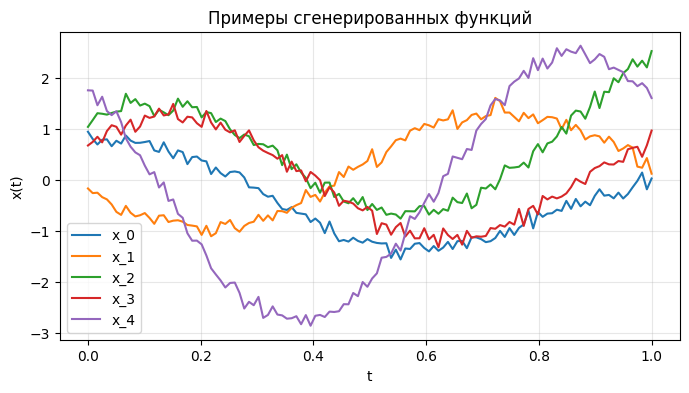

In [3]:
sample_ids = np.arange(5)
ax = plot_functions(
    t,
    X_func[sample_ids],
    labels=[f"x_{i}" for i in sample_ids],
    title="Примеры сгенерированных функций",
    xlabel="t",
    ylabel="x(t)",
)
plt.show()

**Рисунок 1. Примеры сгенерированных функций.**

Кривые состоят из синусоидальной, косинусоидальной и линейной частей. Случайные
коэффициенты меняют амплитуду и наклон, а шум создает небольшие локальные
колебания. Такая генерация дает разные объекты, но сохраняет общую структуру,
которую должны улавливать функциональные признаки.

## 3. Построение функциональных признаков

Рассматриваются два способа построения признаков:

1. средние значения функции на подотрезках;
2. интегралы с тригонометрическими функциями.

В обоих случаях каждая строка матрицы $Z$ соответствует одной исходной функции.

In [4]:
Z_piece_train, piece_basis, piece_names, piece_edges = build_piecewise_features(
    X_train_func, t, M_FUNCTIONALS, use_average=True
)
Z_piece_test, _, _, _ = build_piecewise_features(
    X_test_func, t, M_FUNCTIONALS, use_average=True
)

Z_trig_train, trig_basis_values, trig_names = build_trig_features(
    X_train_func, t, M_FUNCTIONALS
)
Z_trig_test, _, _ = build_trig_features(X_test_func, t, M_FUNCTIONALS)

feature_shapes = pd.DataFrame(
    {
        "features": ["piecewise", "trigonometric"],
        "train shape": [Z_piece_train.shape, Z_trig_train.shape],
        "test shape": [Z_piece_test.shape, Z_trig_test.shape],
    }
)
feature_shapes

,features,train shape,test shape
0,piecewise,"(240, 10)","(80, 10)"
1,trigonometric,"(240, 10)","(80, 10)"


In [5]:
pd.DataFrame(Z_trig_train[:5], columns=trig_names).round(3)

,1,sin(1),cos(1),sin(2),cos(2),sin(3),cos(3),sin(4),cos(4),sin(5)
0,-0.076,-0.025,0.377,0.020,0.012,0.002,0.007,0.008,-0.002,0.007
1,0.119,0.380,-0.417,-0.026,-0.001,-0.023,-0.001,-0.005,0.010,-0.008
2,-0.049,0.513,-0.232,0.002,-0.009,0.009,-0.008,0.000,-0.007,0.007
3,-0.287,0.216,-0.259,0.031,-0.002,0.028,0.009,0.019,-0.018,0.024
4,0.168,0.000,-0.790,-0.031,-0.004,-0.020,-0.002,-0.010,-0.003,-0.011


Обе матрицы имеют
размер $(240, 10)$ для обучающей и $(80, 10)$ для тестовой выборки. В
кусочно-постоянном варианте столбцы являются локальными средними на
подотрезках, а в тригонометрическом — проекциями на константу и гармоники.

## 4. Модель МНК

После построения $Z$ задача становится обычной линейной регрессией:

$$
\hat y_i = \beta_0 + \sum_{k=1}^{m}\beta_k z_{ik}.
$$

In [6]:
ols_piece = fit_ols(Z_piece_train, y_train)
ols_trig = fit_ols(Z_trig_train, y_train)

ols_piece_eval = evaluate_model(ols_piece, Z_piece_train, y_train, Z_piece_test, y_test)
ols_trig_eval = evaluate_model(ols_trig, Z_trig_train, y_train, Z_trig_test, y_test)

ols_table = pd.DataFrame(
    [
        {"model": "OLS", "functional features": "piecewise", **ols_piece_eval["test"]},
        {"model": "OLS", "functional features": "trigonometric", **ols_trig_eval["test"]},
    ]
).round(4)
ols_table

,model,functional features,MSE,RMSE,R2
0,OLS,piecewise,0.0105,0.1025,0.9937
1,OLS,trigonometric,0.0104,0.1017,0.9938


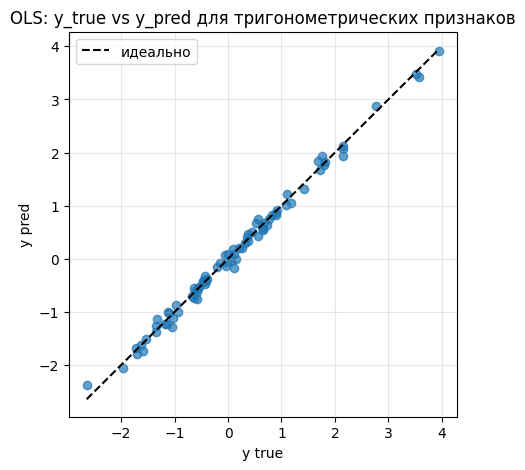

In [7]:
plot_true_vs_pred(
    y_test,
    ols_trig_eval["pred_test"],
    title="OLS: y_true vs y_pred для тригонометрических признаков",
)
plt.show()

**Рисунок 2. Истинные и
предсказанные значения OLS с тригонометрическими признаками.**

Точки расположены близко к диагонали, что согласуется с $R^2=0.9938$ и
$RMSE=0.1017$. Два набора признаков дают почти одинаковое качество: тестовая
$MSE$ равна $0.0105$ для локальных средних и $0.0104$ для
тригонометрических признаков.

## 5. Ridge-регрессия

Ridge-регрессия добавляет штраф на норму коэффициентов:

$$
Q_\lambda(\beta) = \|y - Z\beta\|_2^2 + \lambda\|\beta\|_2^2.
$$

В этом разделе используется одно фиксированное значение $\lambda$, а ниже оно будет перебираться отдельно.

In [8]:
ridge_piece = fit_ridge(Z_piece_train, y_train, alpha=RIDGE_ALPHA)
ridge_trig = fit_ridge(Z_trig_train, y_train, alpha=RIDGE_ALPHA)

ridge_piece_eval = evaluate_model(ridge_piece, Z_piece_train, y_train, Z_piece_test, y_test)
ridge_trig_eval = evaluate_model(ridge_trig, Z_trig_train, y_train, Z_trig_test, y_test)

ridge_table = pd.DataFrame(
    [
        {"model": "Ridge", "functional features": "piecewise", "alpha": RIDGE_ALPHA, **ridge_piece_eval["test"]},
        {"model": "Ridge", "functional features": "trigonometric", "alpha": RIDGE_ALPHA, **ridge_trig_eval["test"]},
    ]
).round(4)
ridge_table

,model,functional features,alpha,MSE,RMSE,R2
0,Ridge,piecewise,0.1,0.0103,0.1015,0.9938
1,Ridge,trigonometric,0.1,0.0101,0.1006,0.9939


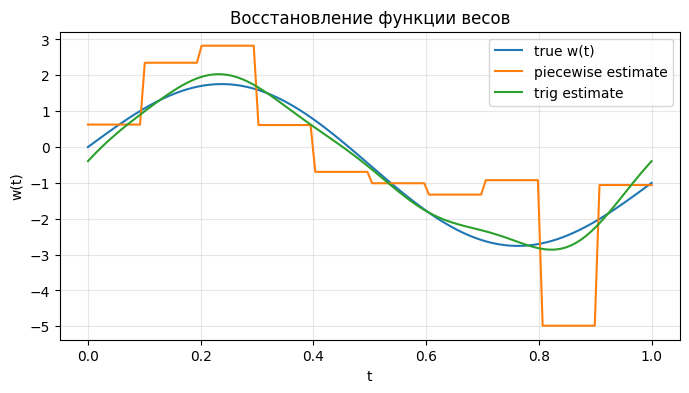

In [9]:
w_true = true_weight_function(t)
w_piece = recover_piecewise_weight(t, ridge_piece.coef_, piece_edges, use_average=True)
w_trig = recover_weight_from_basis(ridge_trig.coef_, trig_basis_values)

plot_functions(
    t,
    [w_true, w_piece, w_trig],
    labels=["true w(t)", "piecewise estimate", "trig estimate"],
    title="Восстановление функции весов",
    xlabel="t",
    ylabel="w(t)",
)
plt.show()

**Рисунок 3. Восстановление функции
весов.**

Тригонометрическая оценка хорошо повторяет плавную форму истинной функции
$w(t)=2\sin(2\pi t)-t$. Кусочно-постоянная оценка передает общий ход, но
получается ступенчатой и сильнее колеблется на правой части отрезка. Это
объясняется способом задания базиса и шумом в данных.

## 6. Сравнение систем функционалов

Соберем результаты МНК и Ridge в одну таблицу, чтобы сравнение было более наглядным.

In [10]:
comparison_table = pd.concat([ols_table, ridge_table.drop(columns=["alpha"])], ignore_index=True)
comparison_table.sort_values(["functional features", "model"]).reset_index(drop=True)

,model,functional features,MSE,RMSE,R2
0,OLS,piecewise,0.0105,0.1025,0.9937
1,Ridge,piecewise,0.0103,0.1015,0.9938
2,OLS,trigonometric,0.0104,0.1017,0.9938
3,Ridge,trigonometric,0.0101,0.1006,0.9939


При
$m=10$ лучшее качество показала Ridge-модель с тригонометрическими признаками:
$MSE=0.0101$, $RMSE=0.1006$, $R^2=0.9939$. Разница между всеми четырьмя
вариантами мала, поэтому главный плюс тригонометрической системы в этом
эксперименте — более естественное восстановление гладкой функции весов.

## 7. Влияние числа функционалов

Теперь проверяется, как меняется качество при разном числе признаков $m$. Для простоты используется МНК, а ошибка измеряется на train и test.

In [11]:
m_values = [2, 4, 6, 8, 10, 15, 20]
rows = []

for m in m_values:
    Zp_train, _, _, _ = build_piecewise_features(X_train_func, t, m, use_average=True)
    Zp_test, _, _, _ = build_piecewise_features(X_test_func, t, m, use_average=True)
    model_p = fit_ols(Zp_train, y_train)
    eval_p = evaluate_model(model_p, Zp_train, y_train, Zp_test, y_test)

    Zt_train, _, _ = build_trig_features(X_train_func, t, m)
    Zt_test, _, _ = build_trig_features(X_test_func, t, m)
    model_t = fit_ols(Zt_train, y_train)
    eval_t = evaluate_model(model_t, Zt_train, y_train, Zt_test, y_test)

    rows.append({"m": m, "features": "piecewise", "train_MSE": eval_p["train"]["MSE"], "test_MSE": eval_p["test"]["MSE"]})
    rows.append({"m": m, "features": "trigonometric", "train_MSE": eval_t["train"]["MSE"], "test_MSE": eval_t["test"]["MSE"]})

m_table = pd.DataFrame(rows)
m_table.round(4)

,m,features,train_MSE,test_MSE
0,2,piecewise,0.0094,0.0101
1,2,trigonometric,0.0093,0.0101
2,4,piecewise,0.0092,0.0102
3,4,trigonometric,0.0090,0.0102
4,6,piecewise,0.0090,0.0101
5,6,trigonometric,0.0090,0.0100
6,8,piecewise,0.0088,0.0103
7,8,trigonometric,0.0089,0.0101
8,10,piecewise,0.0090,0.0105
9,10,trigonometric,0.0088,0.0104


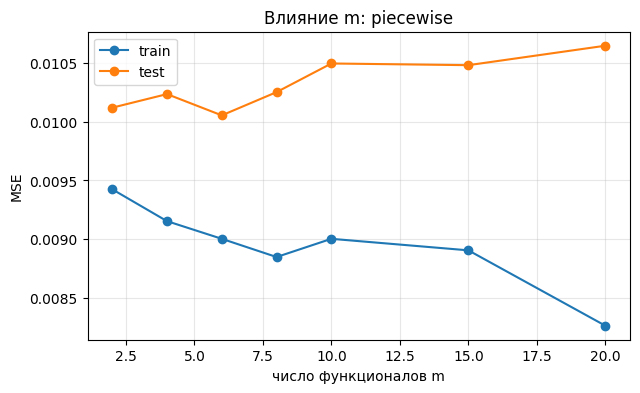

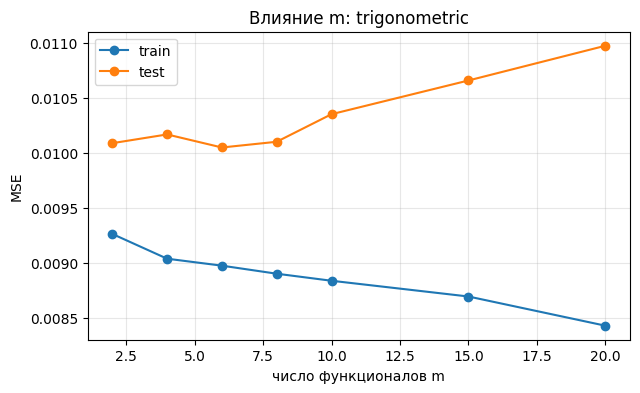

In [12]:
for feature_name in ["piecewise", "trigonometric"]:
    part = m_table[m_table["features"] == feature_name]
    plot_error_curve(
        part["m"],
        part["train_MSE"],
        part["test_MSE"],
        xlabel="число функционалов m",
        ylabel="MSE",
        title=f"Влияние m: {feature_name}",
    )
    plt.show()

**Рисунки
4–5. Зависимость train- и test-MSE от числа функционалов.**

Минимум test-MSE достигается примерно при $m=6$: $0.0101$ для локальных
средних и $0.0100$ для тригонометрических признаков. При дальнейшем росте
$m$ train-ошибка в целом уменьшается, а test-ошибка растет до $0.0106$ и
$0.0110$ при $m=20$. Значит, дополнительные функционалы начинают описывать
шум, а не полезный сигнал.

## 8. Влияние регуляризации

Здесь фиксируется тригонометрическая система признаков, а параметр $\lambda$ перебирается по логарифмической сетке.

In [13]:
lambda_values = np.logspace(-4, 2, 10)
lambda_rows = []

for alpha in lambda_values:
    model = fit_ridge(Z_trig_train, y_train, alpha=alpha)
    result = evaluate_model(model, Z_trig_train, y_train, Z_trig_test, y_test)
    lambda_rows.append(
        {
            "lambda": alpha,
            "train_RMSE": result["train"]["RMSE"],
            "test_RMSE": result["test"]["RMSE"],
            "test_R2": result["test"]["R2"],
        }
    )

lambda_table = pd.DataFrame(lambda_rows)
lambda_table.round(4)

,lambda,train_RMSE,test_RMSE,test_R2
0,0.0001,0.0940,0.1017,0.9938
1,0.0005,0.0940,0.1016,0.9938
2,0.0022,0.0941,0.1012,0.9938
3,0.0100,0.0945,0.1006,0.9939
4,0.0464,0.0953,0.1005,0.9939
5,0.2154,0.0958,0.1008,0.9939
6,1.0000,0.0979,0.1044,0.9934
7,4.6416,0.1294,0.1437,0.9876
8,21.5443,0.3314,0.3685,0.9181
9,100.0000,0.7503,0.8264,0.5881


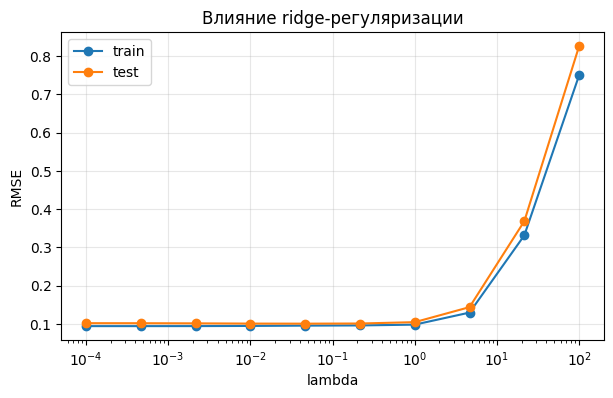

In [14]:
ax = plot_error_curve(
    lambda_table["lambda"],
    lambda_table["train_RMSE"],
    lambda_table["test_RMSE"],
    xlabel="lambda",
    ylabel="RMSE",
    title="Влияние ridge-регуляризации",
)
ax.set_xscale("log")
plt.show()

**Рисунок 6. Зависимость качества
Ridge от параметра $\lambda$.**

При малых $\lambda$ результат почти совпадает с МНК. Наименьший test-RMSE
$0.1005$ получен при $\lambda\approx0.0464$; значение $0.1$, использованное в
основном эксперименте, находится рядом с минимумом. После $\lambda=1$
ошибка быстро растет, поскольку штраф чрезмерно уменьшает коэффициенты.

## 9. Устойчивость к шуму и сетке

В последнем эксперименте меняются уровень шума в функциях и число точек сетки. Это грубая проверка того, насколько качество зависит от дискретизации и случайных возмущений.

In [15]:
noise_values = [0.02, 0.10, 0.25]
grid_values = [50, 100, 200]
stability_rows = []

for noise in noise_values:
    for n_grid in grid_values:
        t_tmp, X_tmp, y_tmp, _ = generate_functional_data(
            n_samples=N_SAMPLES,
            n_points=n_grid,
            x_noise=noise,
            y_noise=Y_NOISE,
            random_state=RANDOM_STATE,
        )
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_tmp, y_tmp, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
        Z_tr, _, _ = build_trig_features(X_tr, t_tmp, M_FUNCTIONALS)
        Z_te, _, _ = build_trig_features(X_te, t_tmp, M_FUNCTIONALS)
        model = fit_ridge(Z_tr, y_tr, alpha=RIDGE_ALPHA)
        result = evaluate_model(model, Z_tr, y_tr, Z_te, y_te)

        stability_rows.append(
            {
                "x_noise": noise,
                "n_grid": n_grid,
                "test_RMSE": result["test"]["RMSE"],
                "test_R2": result["test"]["R2"],
            }
        )

stability_table = pd.DataFrame(stability_rows)
stability_table.round(4)

,x_noise,n_grid,test_RMSE,test_R2
0,0.02,50,0.0955,0.9945
1,0.02,100,0.0960,0.9943
2,0.02,200,0.0980,0.9941
3,0.10,50,0.0950,0.9946
4,0.10,100,0.0961,0.9943
5,0.10,200,0.0979,0.9941
6,0.25,50,0.0947,0.9947
7,0.25,100,0.0966,0.9942
8,0.25,200,0.0974,0.9942


In [16]:
pivot_rmse = stability_table.pivot(index="x_noise", columns="n_grid", values="test_RMSE")
pivot_rmse.round(4)

n_grid,50,100,200
x_noise,,,
0.02,0.0955,0.0960,0.0980
0.10,0.0950,0.0961,0.0979
0.25,0.0947,0.0966,0.0974


В
проверенном диапазоне результат устойчив к шуму в функциях и плотности сетки:
test-RMSE остается между $0.0947$ и $0.0980$, а $R^2$ — между $0.9941$ и
$0.9947$. Увеличение сетки с 50 до 200 точек не улучшило качество, поэтому
50–120 точек уже достаточно для этого способа генерации и численного
интегрирования.

## 10. Аналитическая и численная проверка линейности

Для $L_\varphi(x)=\int_0^1 x(t)\varphi(t)\,dt$ и любых чисел
$\alpha,\gamma$:

$$
L_\varphi(\alpha x_1+\gamma x_2)
=\int_0^1(\alpha x_1(t)+\gamma x_2(t))\varphi(t)\,dt
=\alpha L_\varphi(x_1)+\gamma L_\varphi(x_2).
$$

Локальное среднее также линейно, потому что отличается от интеграла только
делением на постоянную длину подотрезка. Численная проверка ниже дает невязку
порядка $10^{-17}$, то есть отличие связано только с округлением.

In [17]:
from src.case4_functionals import integrate_on_grid

alpha, gamma = 1.7, -0.4
phi = trig_basis_values[1]
left = integrate_on_grid(alpha * X_train_func[0] + gamma * X_train_func[1], t, phi)
right = (
    alpha * integrate_on_grid(X_train_func[0], t, phi)
    + gamma * integrate_on_grid(X_train_func[1], t, phi)
)

pd.DataFrame(
    {
        "check": ["linearity residual"],
        "absolute residual": [abs(left - right)],
    }
)

,check,absolute residual
0,linearity residual,2.775558e-17


## 11. Сравнение устойчивости коэффициентов

Устойчивость оценивается по 30 повторным разбиениям данных. У
тригонометрической OLS среднее стандартное отклонение коэффициентов равно
$0.3435$, а максимальное — $0.6006$. Ridge уменьшает эти значения до
$0.0292$ и $0.0466$. Для локальных средних снижение менее сильное:
$0.0843\to0.0541$ по среднему отклонению. Это согласуется с тем, что
тригонометрическая матрица хуже обусловлена, а регуляризация особенно полезна
при неустойчивых оценках. Прямое сравнение абсолютных коэффициентов двух
систем нужно делать осторожно, потому что признаки имеют разные масштабы.

In [18]:
from sklearn.model_selection import ShuffleSplit

Z_piece_all, _, _, _ = build_piecewise_features(
    X_func, t, M_FUNCTIONALS, use_average=True
)
Z_trig_all, _, _ = build_trig_features(X_func, t, M_FUNCTIONALS)

splitter = ShuffleSplit(
    n_splits=30,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
stability_rows = []

for feature_name, Z_all in [
    ("piecewise", Z_piece_all),
    ("trigonometric", Z_trig_all),
]:
    split_indices = list(splitter.split(Z_all))
    for model_name in ["OLS", "Ridge"]:
        coefficient_samples = []
        condition_numbers = []

        for train_index, _ in split_indices:
            if model_name == "OLS":
                fitted = fit_ols(Z_all[train_index], y[train_index])
            else:
                fitted = fit_ridge(
                    Z_all[train_index],
                    y[train_index],
                    alpha=RIDGE_ALPHA,
                )

            coefficient_samples.append(fitted.coef_)
            design = np.column_stack(
                [np.ones(len(train_index)), Z_all[train_index]]
            )
            condition_numbers.append(np.linalg.cond(design))

        coefficient_samples = np.asarray(coefficient_samples)
        coefficient_std = coefficient_samples.std(axis=0)
        stability_rows.append(
            {
                "features": feature_name,
                "model": model_name,
                "mean coefficient std": coefficient_std.mean(),
                "max coefficient std": coefficient_std.max(),
                "mean design condition number": np.mean(condition_numbers),
            }
        )

coefficient_stability_table = pd.DataFrame(stability_rows)
coefficient_stability_table.round(4)

,features,model,mean coefficient std,max coefficient std,mean design condition number
0,piecewise,OLS,0.0843,0.0996,93.8591
1,piecewise,Ridge,0.0541,0.0647,93.8591
2,trigonometric,OLS,0.3435,0.6006,185.8844
3,trigonometric,Ridge,0.0292,0.0466,185.8844


## 12. Аналитические обоснования модели

Обозначим через $Z\in\mathbb{R}^{n\times m}$ матрицу функциональных
признаков и добавим единичный столбец:
$X=[\mathbf{1},Z]$, $\beta=(\beta_0,\beta_1,\ldots,\beta_m)^T$. Тогда

$$
y=X\beta+\varepsilon.
$$

МНК минимизирует $\|y-X\beta\|_2^2$. После дифференцирования получаются
нормальные уравнения

$$
X^TX\hat\beta=X^Ty.
$$

Если столбцы $X$ линейно независимы, то $X^TX$ обратима и
$\hat\beta=(X^TX)^{-1}X^Ty$. Если это условие нарушено, решение можно
получить через псевдообратную матрицу или регуляризацию.

Так как $z_{ik}=\int_0^1x_i(t)\varphi_k(t)\,dt$, линейная часть модели равна

$$
\sum_{k=1}^m\beta_kz_{ik}
=\int_0^1x_i(t)\left(\sum_{k=1}^m\beta_k\varphi_k(t)\right)dt
=\int_0^1x_i(t)w(t)\,dt,
$$

где $w(t)=\sum_k\beta_k\varphi_k(t)$. Для признаков-локальных средних
масштаб соответствующей индикаторной функции дополнительно делится на длину
подотрезка.

В Ridge свободный член не штрафуется. Для
$P=\operatorname{diag}(0,1,\ldots,1)$ решение имеет вид

$$
\hat\beta_\lambda=(X^TX+\lambda P)^{-1}X^Ty.
$$

Добавка $\lambda P$ уменьшает влияние малых собственных значений матрицы
$X^TX$, поэтому коэффициенты становятся устойчивее, хотя при слишком большом
$\lambda$ появляется заметное смещение.

## 13. Итоговые наблюдения

Функциональная регрессия в этом эксперименте успешно свелась к обычной
линейной регрессии после вычисления интегральных признаков. Все четыре модели
дали $R^2$ около $0.994$, а лучший результат показала Ridge-регрессия с
тригонометрическими признаками ($RMSE=0.1006$). Тригонометрический базис лучше
передает гладкую функцию весов, но его OLS-коэффициенты менее устойчивы.
Небольшая Ridge-регуляризация исправляет эту проблему почти без потери
качества. Для данной выборки достаточно примерно 6–10 функционалов и не менее
50 точек сетки.